1. Use the functions created in homeworks 1–4 to compute a linear or log-linear solution to the following problem:

$$\max_{\{c_t, k_{t+1}\}} \sum_{t=0}^{\infty} \beta^t \log(c_t)$$

$$\text{subj. to } \; c_t + k_{t+1} = A k_t^{\theta}$$

$$k_0 \text{ given.}$$

2. Plot the equilibrium paths for consumption, capital, and output starting from $k_0 = \bar{k}/2$, where $\bar{k}$ is the steady state of the non-linear maximization problem.

### 1.  Method 1: Linear Approximation 

Consider
- State: $x = [k_t]$, Control: $u = [k_{t+1}]$
- Return: $r(k, k') = \log(Ak^\theta - k')$
- Law of motion: $g(k, k') = k'$

Linearize $r$ and $g$ around $(\bar{k}, \bar{k})$ to get $Q, W, R, A, B$, then solve the Riccati equation.

The LQ policy is $\hat{u}_t = -F\,\hat{x}_t$, i.e. $k_{t+1} = \bar{k} - F\,(k_t - \bar{k})$.

In [1]:
include("Riccati.jl")


# ── Parameters ──
A_prod = 1.0
θ = 0.36
β = 0.96

# ── Steady state ──
k_ss = (A_prod * β * θ)^(1 / (1 - θ))
c_ss = A_prod * k_ss^θ - k_ss
y_ss = A_prod * k_ss^θ;

In [2]:
# ══════════════════════════════════════════════════
# Method 1: Linear approximation (in levels)
# ══════════════════════════════════════════════════
x_bar = [k_ss]
u_bar = [k_ss]

r_lin(x, u) = log(A_prod * x[1]^θ - u[1])
g_lin(x, u) = [u[1]]

Q1, W1, R1 = compute_QWR(r_lin, x_bar, u_bar)
A1, B1     = compute_AB(g_lin, x_bar, u_bar)

F1, P1 = solve_riccati(Q1, W1, R1, A1, B1, β)
A_cl1 = A1 - B1 * F1;
println("Q = ", Q1,"\nW = ", W1,"\nR = ", R1,"\nA = ", A1,"\nB = ", B1)
print("policy - F: ", -F1)

Converged in 14 iterations (error ≈ 4.51e-11)
Q = [-9.056864425094345;;]
W = [4.018988475351647;;]
R = [-3.8582287364974373;;]
A = [0.0;;]
B = [1.000000000001;;]
policy - F: [0.3600000260933434;;]

### 1.  Method 2: Log-linear Approximation

Define $\tilde{k}_t = \log k_t$. Rewrite everything in logs:
- State: $\tilde{x} = [\tilde{k}_t]$, Control: $\tilde{u} = [\tilde{k}_{t+1}]$
- Return: $\tilde{r}(\tilde{k}, \tilde{k}') = \log(A\,e^{\theta\tilde{k}} - e^{\tilde{k}'})$
- Law of motion: $\tilde{g}(\tilde{k}, \tilde{k}') = \tilde{k}'$

Linearize around $(\log\bar{k}, \log\bar{k})$ and solve the same LQ problem in log-space.

The policy becomes $\widetilde{k}_{t+1} = \log\bar{k} + \tilde{A}_{cl}\,(\tilde{k}_t - \log\bar{k})$, then $k_{t+1} = e^{\widetilde{k}_{t+1}}$.

In [3]:
# ══════════════════════════════════════════════════
# Method 2: Log-linear approximation
# ══════════════════════════════════════════════════

x_bar_log = [log(k_ss)]
u_bar_log = [log(k_ss)]

r_log(x, u) = log(A_prod * exp(θ * x[1]) - exp(u[1]))
g_log(x, u) = [u[1]]

Q2, W2, R2 = compute_QWR(r_log, x_bar_log, u_bar_log)
A2, B2     = compute_AB(g_log, x_bar_log, u_bar_log)

F2, P2 = solve_riccati(Q2, W2, R2, A2, B2, β)
A_cl2 = A2 - B2 * F2;
println("Q = ", Q2,"\nW = ", W2,"\nR = ", R2,"\nA = ", A2,"\nB = ", B2)

Converged in 6 iterations (error ≈ 2.0e-11)
Q = [-0.0522951126846749;;]
W = [0.14526463365527317;;]
R = [-0.4035125011903062;;]
A = [0.0;;]
B = [1.0000000000065512;;]


#### Compare policy function of loglinear LQ and analytical solution

Log-linear LQ gives $\widetilde{k}_{t+1} = \log\bar{k} + \tilde{A}_{cl}(\tilde{k}_t - \log\bar{k})$, i.e.
$$\log k_{t+1} = (1-\tilde{A}_{cl})\log\bar{k} + \tilde{A}_{cl}\,\log k_t.$$
So **slope** $= \tilde{A}_{cl}$ , **intercept** $= (1-\tilde{A}_{cl})\log\bar{k}$.

**Analytical** policy (Euler + resource): $k_{t+1} = \beta\theta A\,k_t^{\theta}$, hence
$$\log k_{t+1} = \log(\beta\theta A) + \theta\,\log k_t.$$
So **slope** $= \theta$, **intercept** $= \log(\beta\theta A)$. 

In [4]:
# ══════════════════════════════════════════════════
# Compare log-linear policy slope & intercept to analytical
# ══════════════════════════════════════════════════

A_tilde = A_cl2[1, 1]                    # slope in log space: d log k' / d log k  (LQ approximation)
intercept_LQ = (1 - A_tilde) * log(k_ss)

slope_exact = θ
intercept_exact = log(β * θ * A_prod)

println("── Policy in log space: log k_{t+1} = intercept + slope · log k_t ──")
println()
println("Log-linear LQ (from Riccati):")
println("  slope  Ã_cl = ", A_tilde)
println("  intercept  = ", intercept_LQ)
println()
println("Analytical (k' = βθA k^θ):")
println("  slope  θ = ", slope_exact)
println("  intercept  = ", intercept_exact)
println()
println("Difference (LQ - analytical):")
println("  slope:  ", A_tilde - slope_exact)
println("  intercept: ", intercept_LQ - intercept_exact)


── Policy in log space: log k_{t+1} = intercept + slope · log k_t ──

Log-linear LQ (from Riccati):
  slope  Ã_cl = 0.36000052914487723
  intercept  = -1.0624723636111848

Analytical (k' = βθA k^θ):
  slope  θ = 0.36
  intercept  = -1.0624732420522367

Difference (LQ - analytical):
  slope:  5.291448772481999e-7
  intercept: 8.784410518991592e-7


### 2. Simulation and Comparison

Simulate from $k_0 = \bar{k}/2$ for $T = 20$ periods. Compare:
1. **Linear** approximation (Method 1)
2. **Log-linear** approximation (Method 2)
3. **Analytical** solution: $k_{t+1} = \beta\theta A k_t^\theta$ 

In [5]:
# ══════════════════════════════════════════════════
# Simulation from k₀ = k̄/2
# ══════════════════════════════════════════════════

T = 20
k0 = k_ss / 2

# ── Analytical solution: k_{t+1} = βθA k_t^θ ──
k_exact = zeros(T + 1)
k_exact[1] = k0
for t in 1:T
    k_exact[t+1] = β * θ * A_prod * k_exact[t]^θ
end
c_exact = A_prod .* k_exact[1:T].^θ .- k_exact[2:T+1]
y_exact = A_prod .* k_exact[1:T].^θ

# ── Method 1: Linear approximation ──
k_lin = zeros(T + 1)
k_lin[1] = k0
for t in 1:T
    k_hat = k_lin[t] - k_ss
    k_lin[t+1] = k_ss + A_cl1[1,1] * k_hat
end
c_lin = A_prod .* k_lin[1:T].^θ .- k_lin[2:T+1]
y_lin = A_prod .* k_lin[1:T].^θ

# ── Method 2: Log-linear approximation ──
logk_bar = log(k_ss)
k_loglin = zeros(T + 1)
k_loglin[1] = k0
for t in 1:T
    logk_hat = log(k_loglin[t]) - logk_bar
    logk_next = logk_bar + A_cl2[1,1] * logk_hat
    k_loglin[t+1] = exp(logk_next)
end
c_loglin = A_prod .* k_loglin[1:T].^θ .- k_loglin[2:T+1]
y_loglin = A_prod .* k_loglin[1:T].^θ

println("Simulation complete (T=$T, k₀=$(round(k0, digits=4)))")

Simulation complete (T=20, k₀=0.0951)


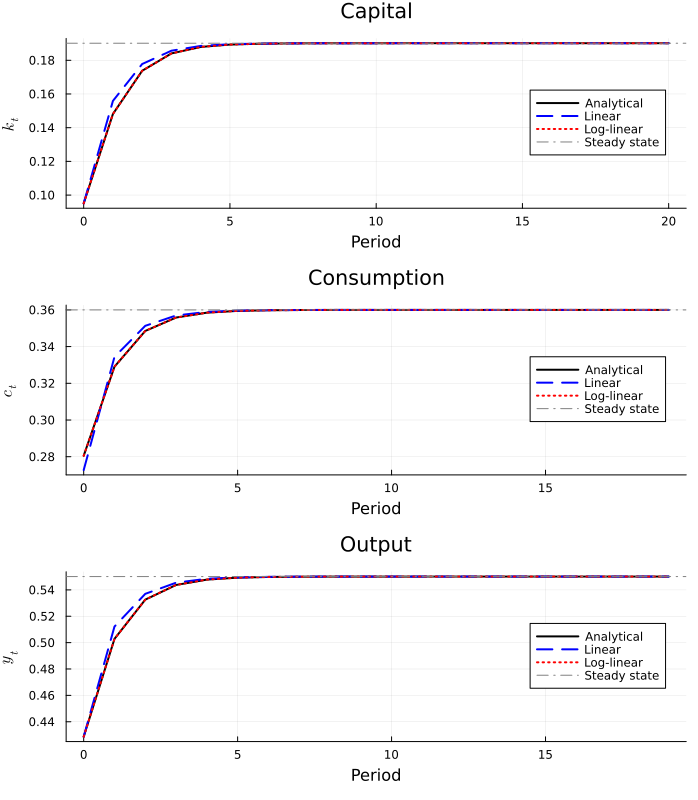

In [6]:
# ══════════════════════════════════════════════════
# Plot equilibrium paths
# ══════════════════════════════════════════════════
using Plots
using LaTeXStrings

periods = 0:T
periods_flow = 0:T-1

p1 = plot(periods, k_exact, label="Analytical", lw=2, ls=:solid, color=:black)
plot!(p1, periods, k_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(p1, periods, k_loglin, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(p1, [k_ss], label="Steady state", ls=:dashdot, color=:gray, lw=1)
xlabel!(p1, "Period")
ylabel!(p1, L"k_t")
title!(p1, "Capital")

p2 = plot(periods_flow, c_exact, label="Analytical", lw=2, ls=:solid, color=:black)
plot!(p2, periods_flow, c_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(p2, periods_flow, c_loglin, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(p2, [c_ss], label="Steady state", ls=:dashdot, color=:gray, lw=1)
xlabel!(p2, "Period")
ylabel!(p2, L"c_t")
title!(p2, "Consumption")

p3 = plot(periods_flow, y_exact, label="Analytical", lw=2, ls=:solid, color=:black)
plot!(p3, periods_flow, y_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(p3, periods_flow, y_loglin, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(p3, [y_ss], label="Steady state", ls=:dashdot, color=:gray, lw=1)
xlabel!(p3, "Period")
ylabel!(p3, L"y_t")
title!(p3, "Output")

plot(p1, p2, p3, layout=(3, 1), size=(700, 800), legend=:right)

### Approximation error vs analytical solution

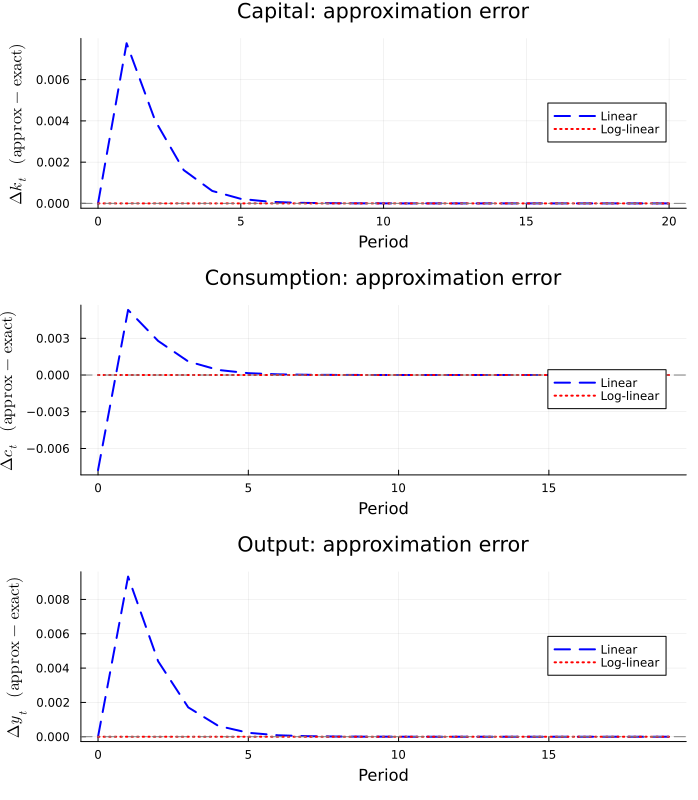

In [7]:
# ══════════════════════════════════════════════════
# Errors: linear & log-linear vs analytical
# ══════════════════════════════════════════════════

err_k_lin  = k_lin .- k_exact
err_k_log  = k_loglin .- k_exact
err_c_lin  = c_lin .- c_exact
err_c_log  = c_loglin .- c_exact
err_y_lin  = y_lin .- y_exact
err_y_log  = y_loglin .- y_exact

q1 = plot(periods, err_k_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(q1, periods, err_k_log, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(q1, [0], ls=:dashdot, color=:gray, lw=1, label="")
xlabel!(q1, "Period")
ylabel!(q1, L"\Delta k_t \quad (\mathrm{approx} - \mathrm{exact})")
title!(q1, "Capital: approximation error")

q2 = plot(periods_flow, err_c_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(q2, periods_flow, err_c_log, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(q2, [0], ls=:dashdot, color=:gray, lw=1, label="")
xlabel!(q2, "Period")
ylabel!(q2, L"\Delta c_t \quad (\mathrm{approx} - \mathrm{exact})")
title!(q2, "Consumption: approximation error")

q3 = plot(periods_flow, err_y_lin, label="Linear", lw=2, ls=:dash, color=:blue)
plot!(q3, periods_flow, err_y_log, label="Log-linear", lw=2, ls=:dot, color=:red)
hline!(q3, [0], ls=:dashdot, color=:gray, lw=1, label="")
xlabel!(q3, "Period")
ylabel!(q3, L"\Delta y_t \quad (\mathrm{approx} - \mathrm{exact})")
title!(q3, "Output: approximation error")

plot(q1, q2, q3, layout=(3, 1), size=(700, 800), legend=:right)

## Linear Approximation with $c_t$ as control

- State: $x = [k_t]$, Control: $u = [c_t]$
- Return: $r(k, c) = \log(c)$
- Law of motion: $g(k, c) = Ak^\theta - c$

Linearize $r$ and $g$ around $(\bar{k}, \bar{c})$. The LQ policy gives $\hat{c}_t = -F_c\,\hat{k}_t$, i.e. $c_t = \bar{c} - F_c(k_t - \bar{k})$, and capital evolves via $k_{t+1} = Ak_t^\theta - c_t$.

In [8]:
# ══════════════════════════════════════════════════
# Linear approximation, control = c_t
# ══════════════════════════════════════════════════

x_bar_c = [k_ss]
u_bar_c = [c_ss]

r_c(x, u) = log(u[1])
g_c(x, u) = [A_prod * x[1]^θ - u[1]]

Qc, Wc, Rc = compute_QWR(r_c, x_bar_c, u_bar_c)
Ac, Bc      = compute_AB(g_c, x_bar_c, u_bar_c)

println("── Linear LQ matrices (control = c) ──")
println("Q = ", Qc, "    (analytical: 0)")
println("W = ", Wc, "    (analytical: 0)")
println("R = ", Rc, "    (analytical: ", -1/(2*c_ss^2), ")")
println("A = ", Ac, "    (analytical: ", A_prod*θ*k_ss^(θ-1), ")")
println("B = ", Bc, "    (analytical: -1)")

Fc, Pc = solve_riccati(Qc, Wc, Rc, Ac, Bc, β)
A_clc = Ac - Bc * Fc

println("\nFeedback F = ", Fc)
println("Closed-loop A_cl = ", A_clc)

── Linear LQ matrices (control = c) ──
Q = [0.0;;]    (analytical: 0)
W = [0.0;;]    (analytical: 0)
R = [-3.8582287364974373;;]    (analytical: -3.858228746260354)
A = [1.0416666671730912;;]    (analytical: 1.0416666666666667)
B = [-1.000000000001;;]    (analytical: -1)
Converged in 738 iterations (error ≈ 9.63e-11)

Feedback F = [-0.04166666823448018;;]
Closed-loop A_cl = [0.9999999989385694;;]


In [19]:
include("Riccati.jl")
include("vaughan.jl")
using LinearAlgebra, Plots, LaTeXStrings

# ══════════════════════════════════════════════════
# Vaughan's Method: Growth Model (linear approx)
#   State x = [k],  Control u = [c]
#   r(k, c) = log(c)
#   g(k, c) = Ak^theta - c    (delta=1, no growth)
# ══════════════════════════════════════════════════

# ── Parameters ──
A_prod = 1.0
theta = 0.36
beta_d = 0.96

# ── Steady state ──
k_ss = (A_prod * beta_d * theta)^(1 / (1 - theta))
c_ss = A_prod * k_ss^theta - k_ss
y_ss = A_prod * k_ss^theta
println("Steady state:  k_ss = ", round(k_ss, digits=6),
        ",  c_ss = ", round(c_ss, digits=6),
        ",  y_ss = ", round(y_ss, digits=6))

# ── Linearization point ──
x_bar = [k_ss]
u_bar = [c_ss]

r_fn(x, u) = log(u[1])
g_fn(x, u) = [A_prod * x[1]^theta - u[1]]

# ── Compute LQ matrices ──
Q, W, R = compute_QWR(r_fn, x_bar, u_bar)
A_mat, B_mat = compute_AB(g_fn, x_bar, u_bar)

println("\nQ = ", round.(Q, digits=6))
println("W = ", round.(W, digits=6))
println("R = ", round.(R, digits=6))
println("A = ", round.(A_mat, digits=6))
println("B = ", round.(B_mat, digits=6))

# ── Transform to standard form ──
Q_tilde, A_tilde, B_tilde = transform_to_standard(Q, W, R, A_mat, B_mat, beta_d)

# ── Solve via Vaughan's method ──
F_v, P_v = solve_vaughan(Q_tilde, R, A_tilde, B_tilde, W)

println("\nF (1x1 via Vaughan) = ", round.(F_v, digits=6))
println("Policy:  c = c_ss - F*(k - k_ss)")

# ── Also solve via Riccati for comparison ──
println("Max |F_vaughan - F_riccati| = ", round(maximum(abs.(F_v - Fc)), sigdigits=3))


Steady state:  k_ss = 0.190117,  c_ss = 0.35999,  y_ss = 0.550108

Q = [0.0;;]
W = [0.0;;]
R = [-3.858229;;]
A = [1.041667;;]
B = [-1.0;;]
Vaughan: eigenvalues of H = [1.0206, 0.9798]

F (1x1 via Vaughan) = [-0.041667;;]
Policy:  c = c_ss - F*(k - k_ss)
Max |F_vaughan - F_riccati| = 5.75e-10


In [22]:
# ══════════════════════════════════════════════════
# Simulate equilibrium paths from k0 = k_ss / 2
# ══════════════════════════════════════════════════

T = 40
k0 = k_ss / 2

k_path = zeros(T + 1)
c_path = zeros(T)
y_path = zeros(T)

k_path[1] = k0

for t in 1:T
    dk = k_path[t] - k_ss
    c_path[t] = c_ss - F_v[1,1] * dk
    y_path[t] = A_prod * k_path[t]^theta
    k_path[t+1] = y_path[t] - c_path[t]
    println(k_path[t+1])
end

0.07259473171712144
0.033885005869568274
-0.05781389353863292


LoadError: DomainError with -0.05781389353863292:
Exponentiation yielding a complex result requires a complex argument.
Replace x^y with (x+0im)^y, Complex(x)^y, or similar.

k converges to 0.0

  (k_ss = 0.1901)


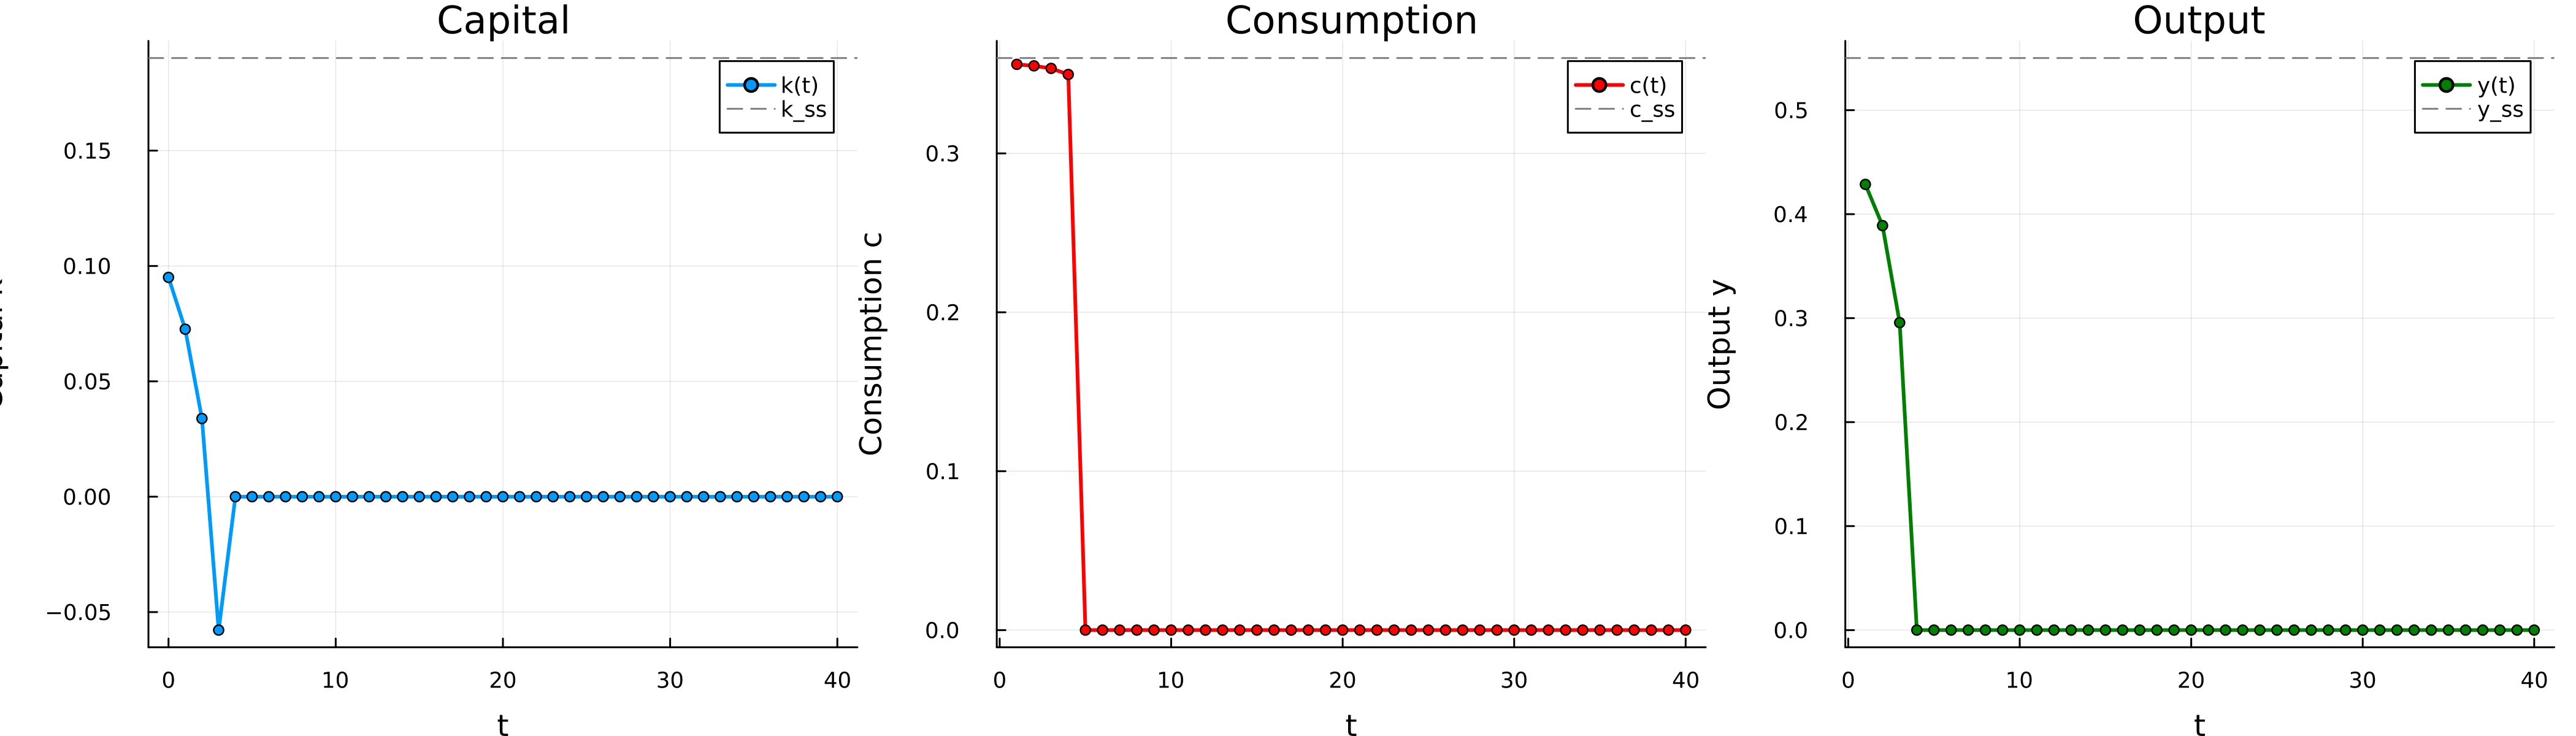

In [23]:
println("k converges to ", round(k_path[end], digits=4), "  (k_ss = ", round(k_ss, digits=4), ")")

# ── Plot equilibrium paths ──
p1 = plot(0:T, k_path, lw=2, label="k(t)", marker=:circle, ms=3)
hline!(p1, [k_ss], ls=:dash, color=:gray, label="k_ss")
xlabel!(p1, "t"); ylabel!(p1, "Capital k"); title!(p1, "Capital")

p2 = plot(1:T, c_path, lw=2, label="c(t)", marker=:circle, ms=3, color=:red)
hline!(p2, [c_ss], ls=:dash, color=:gray, label="c_ss")
xlabel!(p2, "t"); ylabel!(p2, "Consumption c"); title!(p2, "Consumption")

p3 = plot(1:T, y_path, lw=2, label="y(t)", marker=:circle, ms=3, color=:green)
hline!(p3, [y_ss], ls=:dash, color=:gray, label="y_ss")
xlabel!(p3, "t"); ylabel!(p3, "Output y"); title!(p3, "Output")

plot(p1, p2, p3, layout=(1, 3), size=(1400, 400),
     dpi=300, bottom_margin=5Plots.mm, left_margin=3Plots.mm)